# Stack Overflow Developer Survey Analysis  
## IBM Data Analyst Capstone Project

--------------------
### EXPLORATORY DATA ANALYSIS
--------------------

In [1]:
import pandas as pd

df = pd.read_csv("../data/01_data_collection_cleaned_survey.csv")

df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,I prefer not to say,"Independent contractor, freelancer, or self-employed","Not employed, and not looking for work","Not employed, but looking for work",Retired,"Student, full-time","Student, part-time",Experience_Level,Experience_group,Employment_group
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary,Books / Physical media,NaN,...,0,0,0,0,0,0,0,Mid,6-10,Full-time
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor's degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0,0,0,0,0,0,0,Senior,11-20,Full-time
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master's degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0,0,0,0,0,0,0,Expert,20+,Full-time
3,4,I am learning to code,18-24 years old,"Student, full-time","Hybrid (some remote, some in-person)",Apples,Unknown,Some college,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,0,0,0,0,0,1,0,Mid,6-10,Student
4,5,I am a developer by profession,18-24 years old,"Student, full-time","Hybrid (some remote, some in-person)",Apples,Unknown,Secondary,"Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,0,0,0,0,0,1,0,Mid,6-10,Student


### 📌 Identifying Missing Values

In [2]:
#Checking all missing Values

cols =["Employment", "RemoteWork", "JobSat"]
 

missing_df = pd.DataFrame({
"Missing Values": df.isnull().sum(),
"Missing %": (df.isnull().sum() / len(df) * 100)
}).sort_values(by = "Missing Values", ascending = False)

missing_df[missing_df["Missing Values"] > 0 ]

,Missing Values,Missing %
AINextMuch less integrated,64289,98.245641
AINextLess integrated,63082,96.401119
AINextNo change,52939,80.900714
AINextMuch more integrated,51999,79.464217
EmbeddedAdmired,48704,74.428840
...,...,...
SOAccount,5877,8.981157
LanguageHaveWorkedWith,5692,8.698443
NEWSOSites,5151,7.871693
LearnCode,4949,7.563000


In [3]:
# Missing Values of Employment, RemoteWork, JobSat

cols =["Employment", "RemoteWork", "JobSat"]

for col in cols: 
    print(f"{col} Missing values: {df[col].isnull().sum()}")


Employment Missing values: 0
RemoteWork Missing values: 0
JobSat Missing values: 36311


In [4]:
# Missing Values (%) of Employment, RemoteWork, JobSat 
 
summary = pd.DataFrame({
    "Missing Values": df[cols].isnull().sum(),
    "Missing %" : df[cols].isnull().mean() * 100
})

summary = summary.sort_values(by = "Missing Values", ascending = False)
summary

,Missing Values,Missing %
JobSat,36311,55.490013
Employment,0,0.000000
RemoteWork,0,0.000000


In [5]:
df_clean = df.dropna(subset=["JobSat"])

In [6]:
df["JobSat"].isnull().sum()

np.int64(36311)

#### 📌 Analysing Experience and Job Satisfaction¶

/var/folders/b3/_4r5vrzn66v143p2jr_t60p40000gn/T/ipykernel_6375/2227804716.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_job = df.groupby("Experience_group")["JobSat"].median()


<Axes: title={'center': 'Job Satisfaction by Experience Level'}, xlabel='Experience_group'>

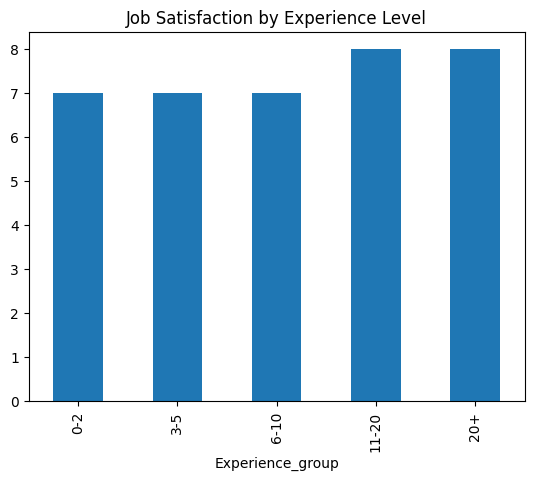

In [7]:
df[["YearsCodePro", "JobSat"]].describe()
df[["YearsCodePro", "JobSat"]].dtypes
df["YearsCodePro"].max()

bins = [0,2,5,10,20,50]
labels = ["0-2", "3-5", "6-10", "11-20", "20+"]

df["Experience_group"] = pd.cut(
    df["YearsCodePro"], 
    bins = bins, 
    labels = labels, 
    include_lowest = True)

df["Experience_group"].value_counts()

median_job = df.groupby("Experience_group")["JobSat"].median()

median_job.plot(kind="bar", title="Job Satisfaction by Experience Level")

#### 📌  Visualizying Job Satisfaction¶

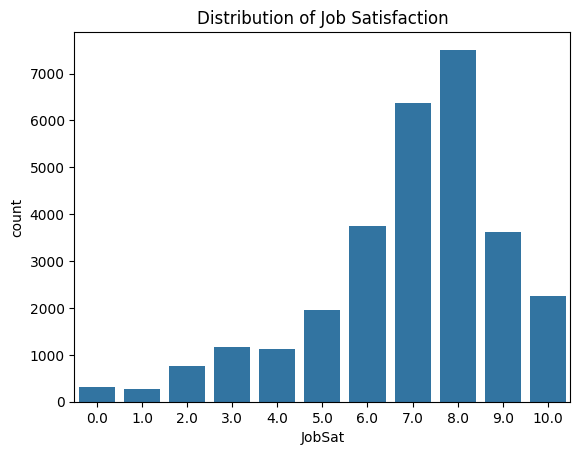

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="JobSat", data=df)

plt.title("Distribution of Job Satisfaction")
plt.show()

#### 📌 Analyzing Remote Work Preferences by Job Role

Text(0.5, 1.0, 'Employment Distribution')

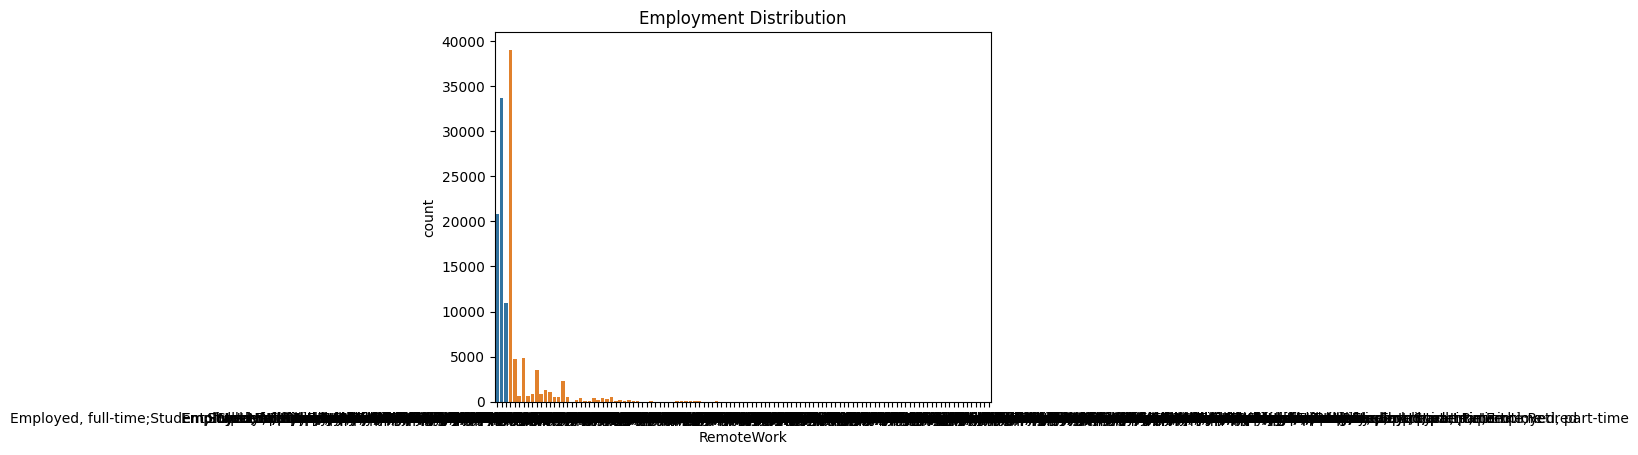

In [9]:
df["RemoteWork"].isnull().sum()
df["Employment"].isnull().sum()


sns.countplot(x= df["RemoteWork"], data = df)
plt.title("Remote Work Distribution")


sns.countplot(x= df["Employment"], data = df)
plt.title("Employment Distribution")


In [10]:
df["RemoteWork"].nunique()
df["Employment"].value_counts()

sorted(df["Employment"].unique())

pd.set_option("display.max_rows", None)
df["Employment"].value_counts()


Employment
Employed, full-time                                                                                                                                                                                                     39041
Independent contractor, freelancer, or self-employed                                                                                                                                                                     4846
Student, full-time                                                                                                                                                                                                       4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                                                                                                 3557
Not employed, but looking for work                                                                   

In [11]:
# Full-time employed

df["Employment_group"] = "Other / Unknown"

df.loc[
    df["Employment"].str.contains("Employed, full-time", na = False),
    "Employment_group"
] = "Full-time"


In [12]:
# Self-employed / freelancer 

df.loc[
    df["Employment"].str.contains("Independent contractor|freelancer|self-employed", na = False),
    "Employment_group"
] = "Self-employed / Freelancer"

In [13]:
# Part-time 
df.loc[
    df["Employment"].str.contains("Employed, part-time", na=False),
    "Employment_group"
] = "Part-time"

In [14]:
# Student
df.loc[
    df["Employment"].str.contains("Student", na = False),
    "Employment_group"
] = "Student"

In [15]:
# Not employed

df.loc[
    df["Employment"].str.contains("Not employed", na = False),
    "Employment_group"
] = "Not employed"

In [16]:
#Retired

df.loc[
    df["Employment"].str.contains("Retired", na = False),
    "Employment_group"
] = "Retired"

In [17]:
df["Employment_group"].value_counts()

Employment_group
Full-time                     39041
Student                        9688
Self-employed / Freelancer     8403
Not employed                   5015
Part-time                      2063
Retired                         681
Other / Unknown                 546
Name: count, dtype: int64

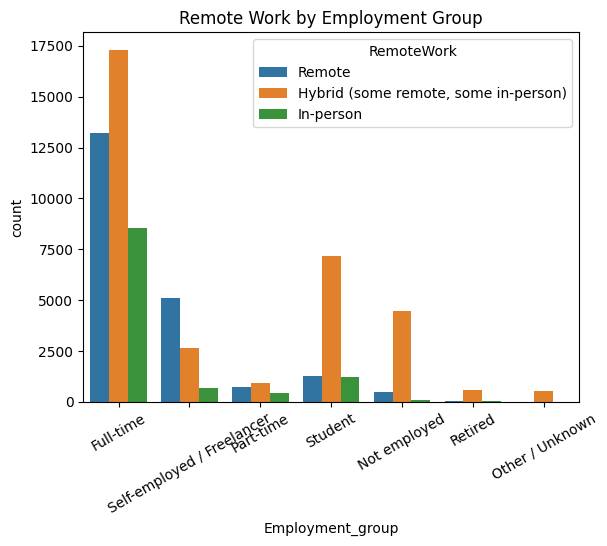

In [18]:
order = [
    "Full-time",
    "Self-employed / Freelancer",
    "Part-time",
    "Student",
    "Not employed",
    "Retired",
    "Other / Unknown"
]

sns.countplot(x="Employment_group", hue="RemoteWork", data=df, order=order)
plt.title("Remote Work by Employment Group")
plt.xticks(rotation=30)
plt.show()

 #### 📌 Analyzing Programming Language Trends by Region

Analyze the popularity of programming languages by region. Use the LanguageHaveWorkedWith column to investigate which languages are most used in different regions.

Filter data by country or region.

Visualize the top programming languages by region with a bar plot or heatmap.

In [19]:
df["LanguageHaveWorkedWith"].isnull().sum()
df["LanguageHaveWorkedWith"].nunique()
df["LanguageHaveWorkedWith"].value_counts()
df_lang = df.dropna(subset=["LanguageHaveWorkedWith"])
df_lang["LanguageHaveWorkedWith"].isnull().sum()

np.int64(0)

In [20]:
df_lang["LanguageHaveWorkedWith"].head()
df_lang["LanguageHaveWorkedWith"].isna().sum()

np.int64(0)

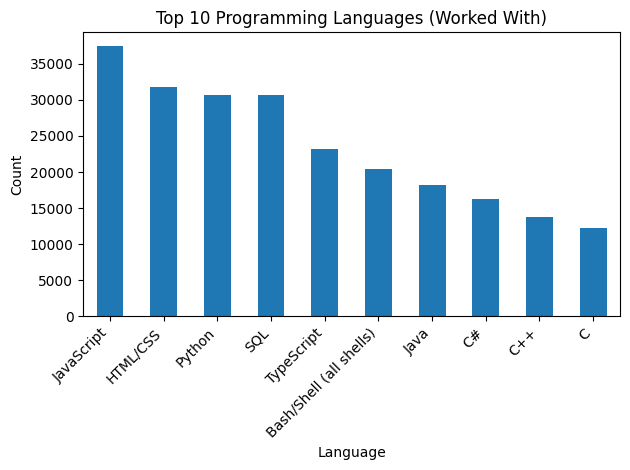

In [21]:
langs = df_lang["LanguageHaveWorkedWith"].str.split(";").explode()
top_langs = langs.value_counts().head(10)

plt.figure()
top_langs.plot(kind="bar")
plt.title("Top 10 Programming Languages (Worked With)")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<Axes: xlabel='Country'>

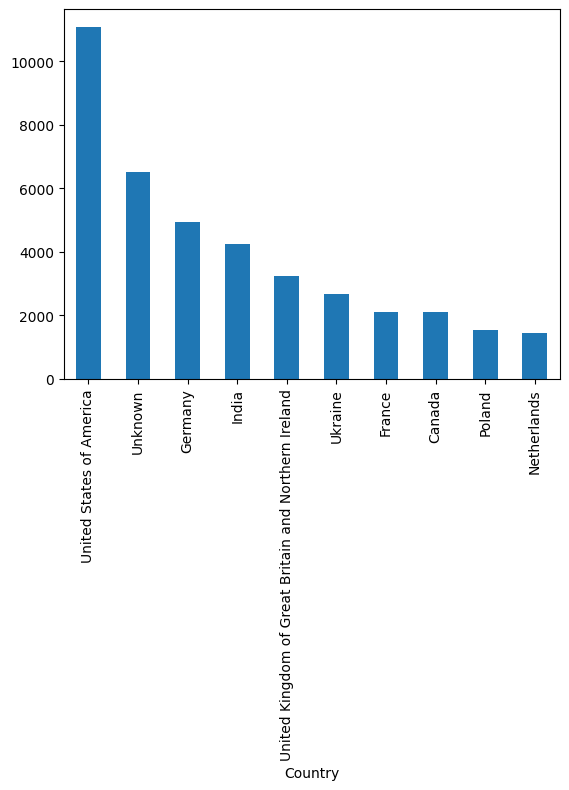

In [22]:
df["Country"].isnull().sum()
df["Country"].unique()
df["Country"].value_counts()
df_poland = df[df["Country"] == "Poland"]
df_poland

df["Country"].value_counts().head(10).plot(kind="bar")

In [23]:
europe_countries = ["Poland", "Germany", "France", "Spain"]

df_europe = df[df["Country"].isin(europe_countries)]
df_europe["Country"].value_counts()

Country
Germany    4947
France     2110
Poland     1534
Spain      1123
Name: count, dtype: int64

<Axes: xlabel='LanguageHaveWorkedWith'>

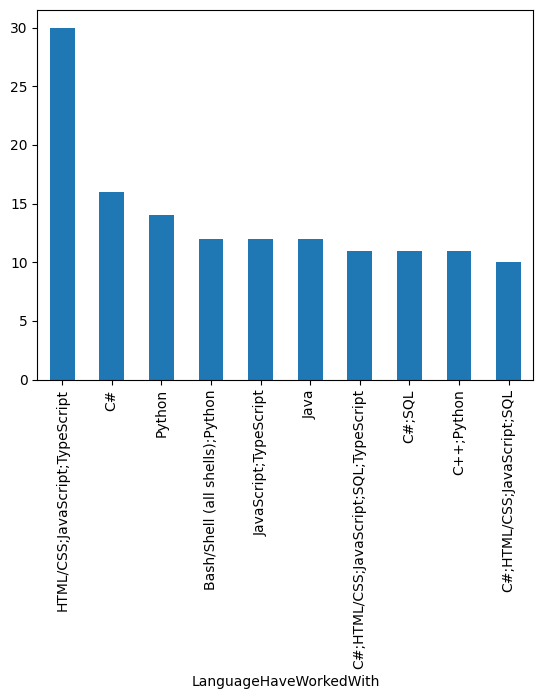

In [24]:
df_poland["LanguageHaveWorkedWith"].value_counts().head(10).plot(kind="bar")

#### 📌 Correlation Between Experience and Satisfaction%cd

In [25]:
df["JobSatPoints_1"].isnull().sum()
df["JobSatPoints_1"].unique()
df["YearsCodePro"].unique()
df["YearsCodePro"].isnull().sum()
df["YearsCodePro"].dtypes
df[["YearsCodePro", "JobSatPoints_1"]].isnull().sum()
df[["YearsCodePro", "JobSatPoints_1"]].dropna().shape

(29324, 2)

In [26]:
df["YearsCodePro"].corr(df["JobSatPoints_1"])

np.float64(-0.031920944811766765)

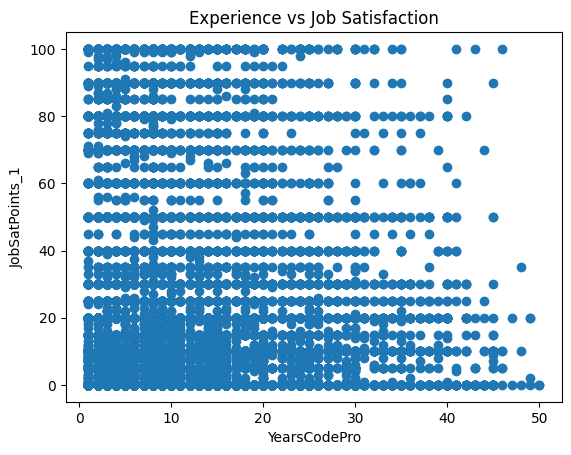

In [27]:
plt.scatter(
    x = df["YearsCodePro"],
    y = df["JobSatPoints_1"]
)

plt.title("Experience vs Job Satisfaction")
plt.xlabel("YearsCodePro")
plt.ylabel("JobSatPoints_1")
plt.show()

### 📌 Educational Background and Employment Type

Explore how educational background (EdLevel) relates to employment type (Employment). Use cross-tabulation and visualizations to understand if higher education correlates with specific employment types.

In [28]:
df[["EdLevel","Employment"]].isnull().sum()
# df["EdLevel"].dtypes

EdLevel       0
Employment    0
dtype: int64

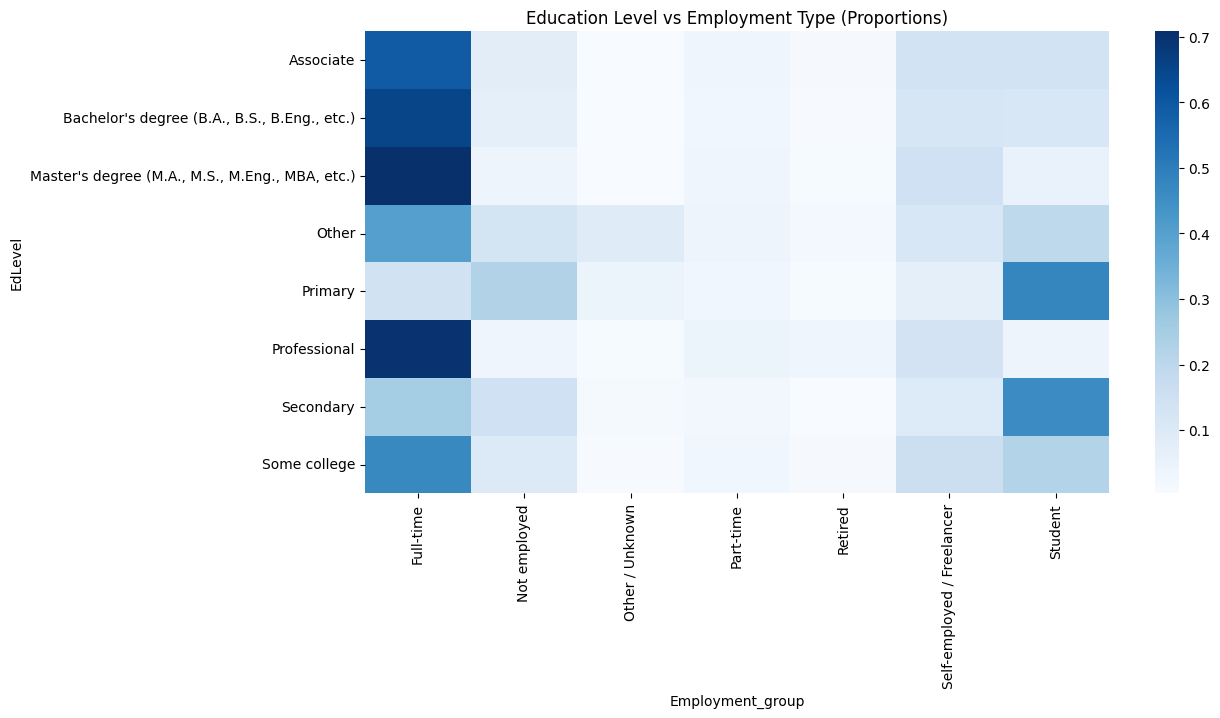

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

ct_norm = pd.crosstab(df["EdLevel"], df["Employment_group"], normalize="index")

plt.figure(figsize=(12,6))
sns.heatmap(ct_norm, cmap="Blues")
plt.title("Education Level vs Employment Type (Proportions)")
plt.show()

--------------------
### ANALYZING THE DATA DISTRIBUTION
#### Finding How The Data Is Distributed
--------------------

### 📌 Job Satisfaction (Focus on JobSat)¶

In [30]:
df.info()
df.dtypes
df.columns
df.describe

df.isnull().sum()
df.isnull().sum().sort_values(ascending=False)

missing = df.isnull().mean().sort_values(ascending=False)
missing


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 133 entries, ResponseId to Employment_group
dtypes: category(1), float64(20), int64(10), object(102)
memory usage: 66.0+ MB


AINextMuch less integrated                              0.982456
AINextLess integrated                                   0.964011
AINextNo change                                         0.809007
AINextMuch more integrated                              0.794642
EmbeddedAdmired                                         0.744288
EmbeddedWantToWorkWith                                  0.731039
EmbeddedHaveWorkedWith                                  0.660528
AIToolNot interested in Using                           0.626908
AINextMore integrated                                   0.626694
Knowledge_9                                             0.577685
Frequency_3                                             0.576539
Knowledge_8                                             0.575806
ProfessionalTech                                        0.575714
Knowledge_7                                             0.575500
Knowledge_6                                             0.574186
Knowledge_5              

In [31]:
df["Employment"].value_counts()
df["JobSat"].value_counts()
df["YearsCodePro"].value_counts()

YearsCodePro
8.0     19282
2.0      4168
3.0      4093
5.0      3526
10.0     3251
4.0      3215
6.0      2843
1.0      2639
7.0      2517
12.0     1777
15.0     1635
20.0     1549
9.0      1493
11.0     1312
13.0     1127
14.0     1082
25.0      998
16.0      946
18.0      867
17.0      814
30.0      689
24.0      632
19.0      516
22.0      492
23.0      448
26.0      426
21.0      380
27.0      380
28.0      342
35.0      285
29.0      196
32.0      194
40.0      194
34.0      169
38.0      134
33.0      132
36.0      119
31.0      106
37.0      104
45.0       56
42.0       55
39.0       54
41.0       51
44.0       42
43.0       37
46.0       21
50.0       14
48.0       14
49.0       11
47.0       10
Name: count, dtype: int64

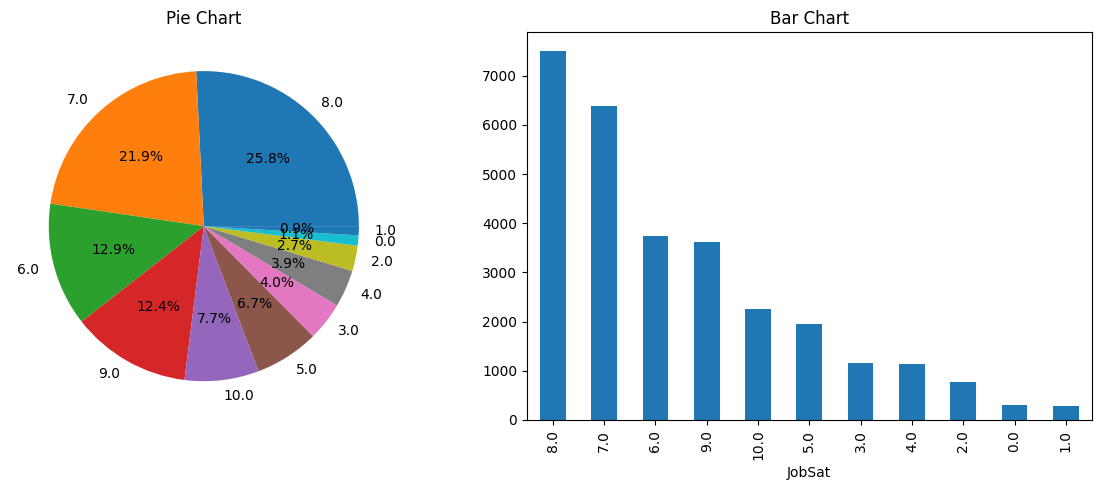

In [32]:
fig, axes = plt.subplots(1, 2, figsize =(12,5))

df["JobSat"].value_counts().plot(
    kind = "pie",
    autopct="%1.1f%%",
    ax=axes[0],
    title="Pie Chart"

)
axes[0].set_ylabel("")

df["JobSat"].value_counts().plot(
    kind="bar",
    ax=axes[1],
    title="Bar Chart"
)

plt.tight_layout()
plt.show()


<p style="color:#666; font-size:13px;">
<u><b>Insight 📌 Job Satisfaction Distribution</b></u><br>
The job satisfaction responses are distributed across multiple levels, with a clear concentration in the middle to positive range (e.g., “Slightly satisfied” and “Satisfied”). This suggests that most respondents experience moderate to positive job satisfaction rather than extreme dissatisfaction or full satisfaction. Overall, the pattern indicates a generally mixed but slightly positive sentiment among developers.
</p>

### 📌  Programming Languages Analysis
##### Analyzing the popularity of programming languages by region.

In [46]:
df[["LanguageHaveWorkedWith", "LanguageWantToWorkWith"]].isnull().sum()

LanguageHaveWorkedWith    5692
LanguageWantToWorkWith    9685
dtype: int64

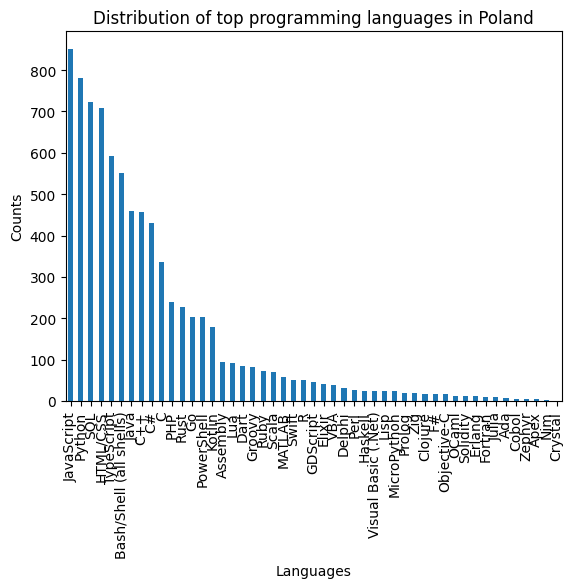

In [66]:
# Poland
df["Country"].isnull().sum()
df_poland = df[df["Country"] == "Poland"]

df_lang_poland = df_poland["LanguageHaveWorkedWith"].str.split(";").explode()

df_lang_poland.value_counts().plot(kind="bar")
plt.title("Distribution of top programming languages in Poland")
plt.xlabel("Languages")
plt.ylabel("Counts")
plt.show()

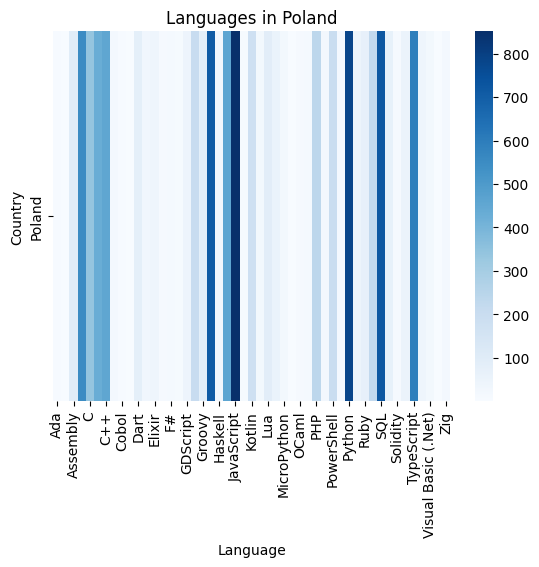

In [77]:
df_poland = df[df["Country"] == "Poland"]

df_exploded = df_poland[["Country", "LanguageHaveWorkedWith"]].dropna()

df_exploded = df_exploded.assign(
    Language=df_exploded["LanguageHaveWorkedWith"].str.split(";")
).explode("Language")

table = pd.crosstab(df_exploded["Country"], df_exploded["Language"])

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(table, cmap="Blues")

plt.title("Distribution of top programming languages in Poland")
plt.show()


--------------------
### HANDLING OUTLIERS
--------------------

--------------------
### CORRELATION
--------------------